# 03.2 — Does the split-half cross statistic measure curvature better? A Swiss roll check

The `curvature-experiments` branch scores its curvature field with a **cross statistic**
rather than a single point estimate: it fits the same geometry twice, independently, and
reports the inner product of the two answers,
$K_H^{\mathrm{cross}} = \langle H^{(A)}, H^{(B)}\rangle$, together with a reliability ratio
$R_H = 2\langle H^{(A)},H^{(B)}\rangle / (\|H^{(A)}\|^2 + \|H^{(B)}\|^2)$ that it uses as an
admissibility gate. Everything in this milestone has instead scored a single-split
$\|H_{\mathrm{est}}\|$.

There is a good reason to expect the cross statistic to be better. The norm of a noisy
vector is **positively biased** — $\mathbb{E}\|H+e\| > \|H\|$ — while the cross statistic is
unbiased, because $\mathbb{E}\langle H+e_A, H+e_B\rangle = \|H\|^2$ when the two errors are
independent and zero-mean. At $d=20$ our measured magnitude ratios were in the hundreds, so
that bias is not a rounding detail.

This notebook asks whether the mechanism actually helps **for the Chart Auto-Encoder**, on
a manifold whose curvature is known in closed form. It imports
`pu_manifold.cross_split_curvature` and `pu_manifold.chart_curvature` unchanged.

**The hinge is the word *independent*.** Two CAE arms trained on disjoint data halves have
independent *sampling* noise, but they share an architecture, a training protocol and a
failure mode. A cross statistic cancels independent error; it cannot cancel a bias both
arms share, and it has no way to report that such a bias exists.

## §1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr

from pu_manifold import cae, chart_curvature, curvature_probe, decoder_curvature
from pu_manifold import cross_split_curvature as csc

SEED = 0
N_POINTS = 3000
CHART_DIM = 2      # the Swiss roll's true intrinsic dimension
EMBED_DIM = 8
N_CHARTS = 4
HIDDEN = [64, 64]
MAX_EPOCHS = 400

# Early stopping is switched OFF deliberately. A first run of this notebook let arm B
# stop at epoch 36 while arm A ran to 200; the two arms were then not comparable, and the
# cross statistic inherited the undertrained arm's error rather than cancelling it.
# 03-08-SUPPLEMENT-03 records the same effect on PU data (removing total-loss early
# stopping cut held-out mse_per_dim by 62.2%). Both arms here run a fixed epoch budget.
NO_EARLY_STOP = 10**9

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"cross_split_curvature: {csc.__file__}")

torch 2.13.0+cpu  numpy 2.5.1
cross_split_curvature: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/cross_split_curvature.py


## §2. The Swiss roll and its known answer

3,000-scale noiseless sheet, centred and divided by one global standard deviation per
`CLAUDE.md`. Colour is the roll's own arc-length parameter `t`, so colour bands staying in
order means the surface stayed in order.

Unlike a reconstruction check, this notebook needs the **curvature** ground truth, not just
the shape: `curvature_probe.swiss_roll_analytic_H_scaled` supplies $\|H\|$ in closed form,
rescaled for the preprocessing. That is what every rank correlation below is scored against.

X (3000, 3)   arm A trains on 1500, arm B on 1500, disjoint
analytic ||H||  p05=0.5705  p50=0.8342  p95=1.5369   spread=2.69x


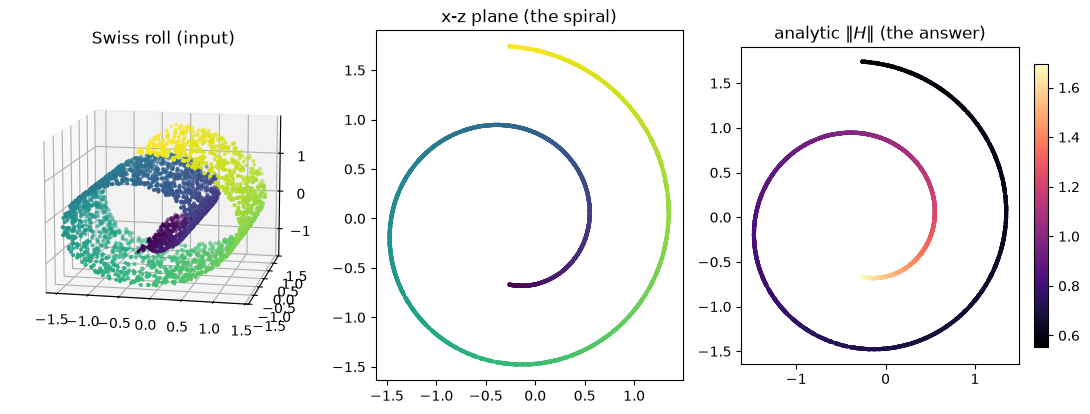

In [2]:
fx = curvature_probe.make_swiss_roll_fixture(n=N_POINTS, seed=SEED)
X, t, global_std = fx["X"], fx["t"], fx["global_std"]
H_true_norm = fx["H_norm"]
H_true_vec = decoder_curvature.swiss_roll_analytic_H_vector(t, global_std)

# The two arms must not share training data -- disjoint halves, not two seeds on one set.
rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
half = N_POINTS // 2
idx_A, idx_B = perm[:half], perm[half:]

x_all32 = torch.tensor(X, dtype=torch.float32)
x_all64 = torch.tensor(X, dtype=torch.float64)

spread = np.percentile(H_true_norm, 95) / np.percentile(H_true_norm, 5)
print(f"X {X.shape}   arm A trains on {len(idx_A)}, arm B on {len(idx_B)}, disjoint")
print(f"analytic ||H||  p05={np.percentile(H_true_norm, 5):.4f}  "
      f"p50={np.percentile(H_true_norm, 50):.4f}  p95={np.percentile(H_true_norm, 95):.4f}"
      f"   spread={spread:.2f}x")

VIEW = dict(elev=12, azim=-78)
fig = plt.figure(figsize=(11, 4.2))
ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW); ax.set_title("Swiss roll (input)")
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("x-z plane (the spiral)"); ax2.set_aspect("equal")
ax3 = fig.add_subplot(1, 3, 3)
sc = ax3.scatter(X[:, 0], X[:, 2], c=H_true_norm, cmap="magma", s=4)
ax3.set_title(r"analytic $\|H\|$ (the answer)"); ax3.set_aspect("equal")
plt.colorbar(sc, ax=ax3, fraction=0.046)
plt.tight_layout(); plt.show()

## §3. Two independent Chart Auto-Encoders

Same `cae.ChartAutoEncoder` and `cae.train_cae` every other notebook uses. Arm A sees only
the first half of the points, arm B only the second. Nothing else differs — same
architecture, same hyperparameters, same epoch budget.

In [3]:
def fit_arm(idx, seed, label):
    torch.manual_seed(seed)
    model = cae.ChartAutoEncoder(
        in_dim=3, embed_dim=EMBED_DIM, chart_dim=CHART_DIM,
        n_charts=N_CHARTS, hidden=HIDDEN, activation="silu",
    )
    fit = cae.train_cae(model, x_all32[idx], {
        "seed": seed, "lr": 1e-3, "weight_decay": 1e-4, "batch": 128,
        "max_epochs": MAX_EPOCHS, "early_stop_patience": NO_EARLY_STOP,
        "early_stop_min_delta": 1e-4, "n_charts": N_CHARTS, "fps_pretrain_epochs": 20,
        "lip_weight": 1e-3, "lip_every_n_steps": 1,
    })
    model.eval()
    with torch.no_grad():
        y = model.reconstruct(x_all32)
        rel = float((torch.linalg.vector_norm(x_all32 - y, dim=-1)
                     / torch.linalg.vector_norm(x_all32, dim=-1)).mean())
    print(f"arm {label}: epochs={fit['epochs_run']}  {fit['wallclock_s']:.0f}s  "
          f"relative error={rel:.4f}")
    return model, rel, y.numpy()

t0 = time.time()
model_A, rel_A, recon_A = fit_arm(idx_A, SEED, "A")
model_B, rel_B, recon_B = fit_arm(idx_B, SEED + 1000, "B")
print(f"both arms trained in {time.time() - t0:.0f}s")

arm A: epochs=400  89s  relative error=0.0083


arm B: epochs=400  170s  relative error=0.0162
both arms trained in 260s


## §4. Both reconstructions, side by side

If either arm has not learned the sheet, its curvature field is not worth crossing with
anything. Colour bands out of order here means that arm failed, and every number in §6
inherits the failure.

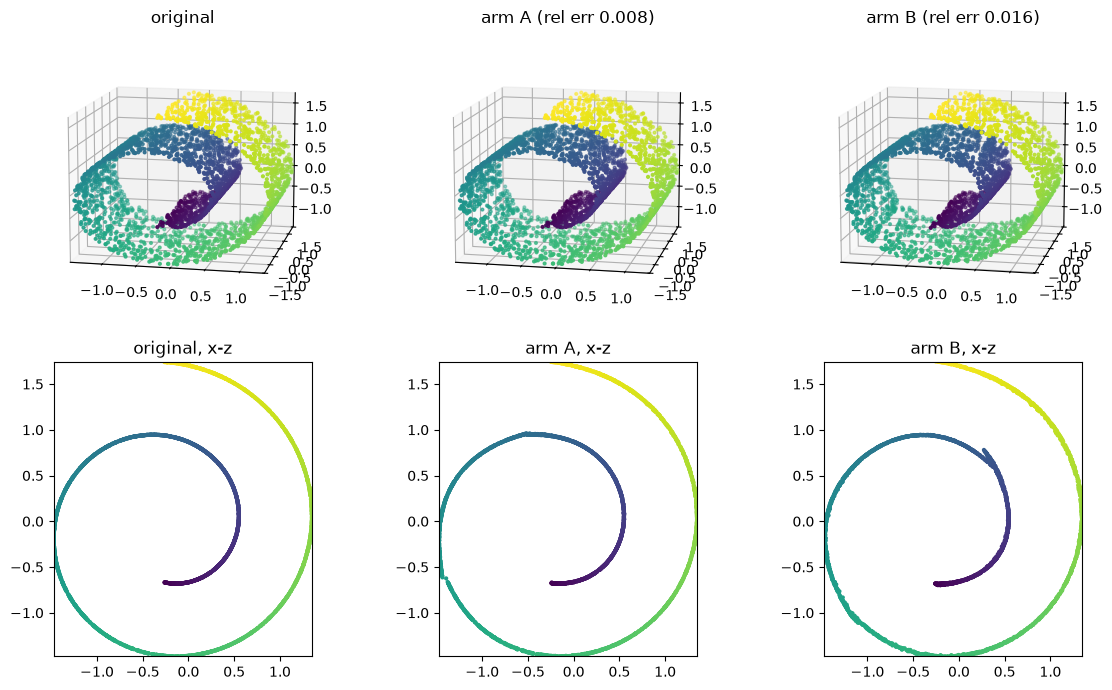

In [4]:
fig = plt.figure(figsize=(12, 7))
panels = [(X, "original"), (recon_A, f"arm A (rel err {rel_A:.3f})"),
          (recon_B, f"arm B (rel err {rel_B:.3f})")]
for i, (data, title) in enumerate(panels):
    ax = fig.add_subplot(2, 3, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap="viridis", s=4)
    ax.view_init(**VIEW); ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max()); ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax2 = fig.add_subplot(2, 3, i + 4)
    ax2.scatter(data[:, 0], data[:, 2], c=t, cmap="viridis", s=4)
    ax2.set_title(f"{title.split(' (')[0]}, x-z"); ax2.set_aspect("equal")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max()); ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
plt.tight_layout(); plt.show()

## §5. Matched baseline

`cae.PlainAutoEncoder` at the same 2-D bottleneck, same width, depth and protocol, trained
on arm A's half. Required by `CLAUDE.md`: if the atlas buys nothing over a single chart,
that is the result.

In [5]:
torch.manual_seed(SEED)
plain = cae.PlainAutoEncoder(3, CHART_DIM, hidden=tuple(HIDDEN), activation="silu")
cae.train_plain_ae(plain, x_all32[idx_A], {
    "seed": SEED, "lr": 1e-3, "weight_decay": 1e-4, "batch": 128,
    "max_epochs": MAX_EPOCHS, "early_stop_patience": NO_EARLY_STOP,
    "early_stop_min_delta": 1e-4,
})
plain.eval()
with torch.no_grad():
    y_plain = plain(x_all32)["y"]
rel_plain = float((torch.linalg.vector_norm(x_all32 - y_plain, dim=-1)
                   / torch.linalg.vector_norm(x_all32, dim=-1)).mean())

print(f"arm A CAE      relative error = {rel_A:.4f}")
print(f"arm B CAE      relative error = {rel_B:.4f}")
print(f"plain AE (d=2) relative error = {rel_plain:.4f}")
print(f"CAE beats matched plain AE    = {min(rel_A, rel_B) < rel_plain}")

arm A CAE      relative error = 0.0083
arm B CAE      relative error = 0.0162
plain AE (d=2) relative error = 0.1126
CAE beats matched plain AE    = True


## §6. The cross statistic against the known answer

Three rank correlations against the analytic $\|H\|$, all on the same points:

- $\rho$ for **arm A alone** — the single-split statistic this milestone has always used.
- $\rho$ for **arm B alone** — the same statistic, other arm.
- $\rho$ for $K_H^{\mathrm{cross}}$ — the cross statistic.

The fair comparison is cross against the **mean** of the two arms, not against the better
one: without ground truth there is no way to pick the better arm, so a single-split user
gets one at random.

$R_H$ is reported alongside. It measures whether the two arms **agree**, which is not the
same question as whether either is **right**.

=== rank correlation against the analytic ||H|| ===
  arm A alone (single split)  rho = +0.8311
  arm B alone (single split)  rho = +0.7522
  mean of the two arms        rho = +0.7917
  K_H_cross  (cross split)    rho = +0.8930
  gain from crossing              = +0.1014

=== reliability: do the two arms AGREE? ===
  median R_H          = 0.9944
  fraction R_H > 0.5  = 1.000
  fraction R_H < 0    = 0.000   (sign disagreement)
  admissible          = True


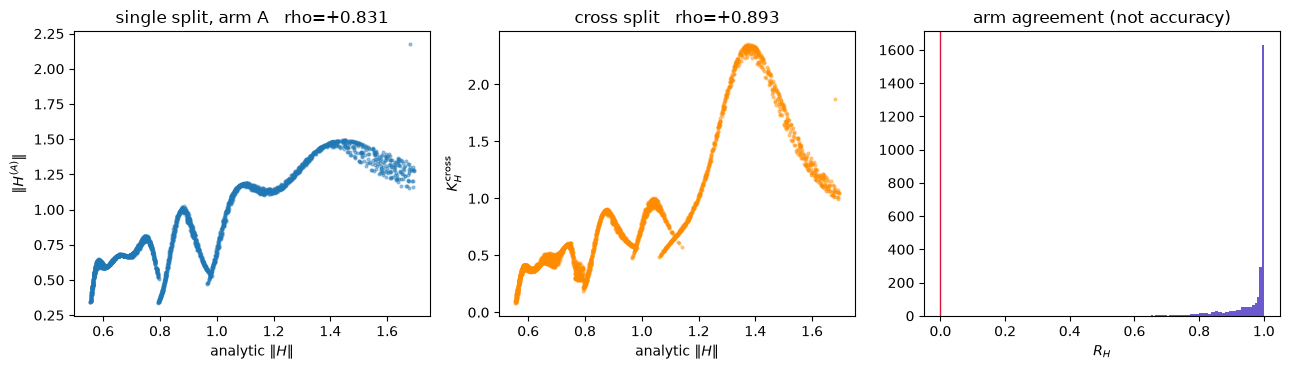

In [6]:
model_A.double(); model_B.double()
field_A = chart_curvature.chart_curvature_field(model_A, x_all64, mode="reverse")
field_B = chart_curvature.chart_curvature_field(model_B, x_all64, mode="reverse")
H_A = field_A["H_vec"].detach().cpu().numpy()
H_B = field_B["H_vec"].detach().cpu().numpy()

out = csc.cross_curvature_field(H_A, H_B, independence="disjoint_data")
rho_A = float(spearmanr(out["norm_H_A"], H_true_norm).statistic)
rho_B = float(spearmanr(out["norm_H_B"], H_true_norm).statistic)
rho_cross = float(spearmanr(out["K_H_cross"], H_true_norm).statistic)
rho_mean_arm = 0.5 * (rho_A + rho_B)
rel_stats = csc.reliability_summary(out["R_H"], threshold=0.5, min_fraction=0.5)

print("=== rank correlation against the analytic ||H|| ===")
print(f"  arm A alone (single split)  rho = {rho_A:+.4f}")
print(f"  arm B alone (single split)  rho = {rho_B:+.4f}")
print(f"  mean of the two arms        rho = {rho_mean_arm:+.4f}")
print(f"  K_H_cross  (cross split)    rho = {rho_cross:+.4f}")
print(f"  gain from crossing              = {rho_cross - rho_mean_arm:+.4f}")
print()
print("=== reliability: do the two arms AGREE? ===")
print(f"  median R_H          = {rel_stats['median_R_H']:.4f}")
print(f"  fraction R_H > 0.5  = {rel_stats['fraction_above']:.3f}")
print(f"  fraction R_H < 0    = {rel_stats['fraction_negative']:.3f}   (sign disagreement)")
print(f"  admissible          = {rel_stats['admissible']}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].scatter(H_true_norm, out["norm_H_A"], s=4, alpha=0.4)
axes[0].set_xlabel(r"analytic $\|H\|$"); axes[0].set_ylabel(r"$\|H^{(A)}\|$")
axes[0].set_title(f"single split, arm A   rho={rho_A:+.3f}")
axes[1].scatter(H_true_norm, out["K_H_cross"], s=4, alpha=0.4, color="darkorange")
axes[1].set_xlabel(r"analytic $\|H\|$"); axes[1].set_ylabel(r"$K_H^{\rm cross}$")
axes[1].set_title(f"cross split   rho={rho_cross:+.3f}")
axes[2].hist(out["R_H"], bins=50, color="slateblue")
axes[2].axvline(0.0, color="crimson", lw=1)
axes[2].set_xlabel(r"$R_H$"); axes[2].set_title("arm agreement (not accuracy)")
plt.tight_layout(); plt.show()

## §7. Read-out

Two separate questions, and they do not have the same answer.

**Does crossing help?** Compare `gain from crossing` against zero. The mechanism is real —
the cross statistic removes a bias the single-split norm has — but it only pays when the
dominant error is *independent between arms*. A shared architecture with a shared failure
mode leaves an error the crossing cannot touch.

**Does $R_H$ certify correctness?** No. High arm agreement alongside mediocre accuracy is
the outcome that matters, because it is exactly the case where a reliability gate passes a
field that does not recover the known answer.

**One seed decides nothing here, and that is a measured statement rather than caution.**
During development the first seed tried gave a gain of $+0.115$ and looked like a clean win;
two further seeds at the same converged settings gave $-0.015$ and $-0.030$, taking the mean
to $+0.019$. The sign of the effect is not stable across seeds at this sample size, so the
cell below reports *this* seed and refuses to generalise from it. The multi-seed number is
produced by `notebooks/diagnostics/cross_split_curvature_sweep_run.py`, which writes a
record per cell and prints the aggregate:

```
python notebooks/diagnostics/cross_split_curvature_sweep_run.py --seeds 0 1 2 --epochs 400
```

In [7]:
gain = rho_cross - rho_mean_arm
arms_trained = max(rel_A, rel_B) < 0.10
beats_baseline = min(rel_A, rel_B) < rel_plain
accurate = rho_cross > 0.90   # the bar spike 002 set for "usable as supervision"

# Two DIFFERENT bars, and conflating them was a real defect in an earlier draft of this
# cell. Missing the 0.90 supervision bar is not the same as failing to see the geometry:
# a field at rho = 0.89 has recovered the ordering and is merely not good enough to
# supervise with. "Reliable but not correct" is only interesting when the arms agree
# closely AND the field is genuinely wrong, which needs its own, much lower, threshold.
CLEARLY_WRONG = 0.60
clearly_wrong = rho_cross < CLEARLY_WRONG

# "Strongly reliable" is a much higher bar than the admissibility gate, which only asks
# that half the points clear R_H > 0.5 and is satisfied by a median of 0.51 -- barely
# distinguishable from arms that agree at chance. The interesting claim needs arms that
# genuinely track each other.
strongly_reliable = (rel_stats["median_R_H"] > 0.90
                     and rel_stats["fraction_negative"] < 0.10)

print(f"both arms reconstruct the roll (<10% rel err) : {arms_trained!s:>5}   "
      f"(A {rel_A:.3f}, B {rel_B:.3f})")
print(f"CAE beats matched plain AE                    : {beats_baseline!s:>5}   "
      f"(plain {rel_plain:.3f})")
print(f"crossing improves rank recovery, THIS seed    : {gain > 0.0!s:>5}   "
      f"({gain:+.4f})")
print(f"arms strongly agree (R_H > 0.90, <10% flips)  : {strongly_reliable!s:>5}   "
      f"(median R_H {rel_stats['median_R_H']:.3f}, "
      f"{100 * rel_stats['fraction_negative']:.1f}% sign flips)")
print(f"cross statistic recovers the known answer     : {accurate!s:>5}   "
      f"(rho {rho_cross:+.4f})")
print()

if not arms_trained:
    print(
        "ARMS NOT TRAINED. At least one arm has not learned the sheet, so nothing below the\n"
        "reconstruction line is interpretable -- a bad arm and a bad statistic look the same\n"
        "from here. Raise MAX_EPOCHS and re-run before reading the curvature numbers."
    )
elif strongly_reliable and clearly_wrong:
    print(
        f"RELIABLE BUT NOT CORRECT -- the outcome this notebook was written to look for.\n"
        f"The two arms track each other closely (median R_H {rel_stats['median_R_H']:.3f}) while\n"
        f"the cross statistic misses the analytic curvature ordering (rho {rho_cross:+.3f},\n"
        f"below {CLEARLY_WRONG}). Split-half reliability certifies that a measurement is\n"
        f"REPRODUCIBLE, never that it is RIGHT: a bias both arms share is perfectly reliable\n"
        f"and invisible to R_H. An admissibility gate built on R_H alone will pass a field\n"
        f"like this one, which is why a known-answer check cannot be replaced by a\n"
        f"reliability check."
    )
elif accurate:
    print(
        "The cross statistic recovers the known curvature ordering on a manifold whose\n"
        "answer is fixed in advance, so the estimator is wired correctly at this seed and a\n"
        "weak result on real data would be about the data."
    )
elif not clearly_wrong:
    print(
        f"ORDERING RECOVERED, SUPERVISION BAR MISSED. rho {rho_cross:+.3f} tracks the analytic\n"
        f"answer clearly, so the estimator sees the geometry at this seed -- but it is under\n"
        f"the 0.90 bar spike 002 set for a signal usable as SUPERVISION. Those are different\n"
        f"claims and only the first is supported here."
    )
else:
    print(
        "The arms reconstruct the sheet but neither agree strongly nor recover the known\n"
        "answer. On this seed the cross statistic is not measuring curvature; treat the\n"
        "gain figure above as uninformative rather than as evidence either way."
    )

print(
    "\nOne seed. The sign of the crossing gain was measured to be seed-unstable during\n"
    "development (+0.115, -0.015, -0.030 at three converged seeds, mean +0.019). Run\n"
    "notebooks/diagnostics/cross_split_curvature_sweep_run.py for the aggregate before\n"
    "quoting any conclusion about whether crossing helps."
)

both arms reconstruct the roll (<10% rel err) :  True   (A 0.008, B 0.016)
CAE beats matched plain AE                    :  True   (plain 0.113)
crossing improves rank recovery, THIS seed    :  True   (+0.1014)
arms strongly agree (R_H > 0.90, <10% flips)  :  True   (median R_H 0.994, 0.0% sign flips)
cross statistic recovers the known answer     : False   (rho +0.8930)

ORDERING RECOVERED, SUPERVISION BAR MISSED. rho +0.893 tracks the analytic
answer clearly, so the estimator sees the geometry at this seed -- but it is under
the 0.90 bar spike 002 set for a signal usable as SUPERVISION. Those are different
claims and only the first is supported here.

One seed. The sign of the crossing gain was measured to be seed-unstable during
development (+0.115, -0.015, -0.030 at three converged seeds, mean +0.019). Run
notebooks/diagnostics/cross_split_curvature_sweep_run.py for the aggregate before
quoting any conclusion about whether crossing helps.
